## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. **Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?**

    The align-before-fuse principle suggests that representations from different modalities should first be projected into a shared semantic space before performing multimodal fusion. In our task (poster image + plot text → genre classification), this means learning unimodal encoders that produce comparable embeddings for semantically related image-text pairs.

    Alignment should occur at the representation level, not the raw token level. We can train image and text encoders with a contrastive objective so that matching poster-plot pairs are close in embedding space while mismatched pairs are separated.

    After alignment, late or mid-level fusion can be applied, such as concatenating embeddings or using cross-attention between the modalities. Because posters and plots describe the same movie but in different forms, semantic alignment at the global representation level should be sufficient for effective fusion.


2. **How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?**

    Controlled experiments
    1. No alignment baseline - Train encoders independently and concatenate their embeddings before classification.
    2. Contrastive alignment + frozen encoders - Pre-train image and text encoders using image-text contrastive learning, then train only the classifier.
	  3. Joint multimodal training - Train encoders and classifier end-to-end without explicit alignment.
    4. Alignment + fusion model - Use contrastive alignment followed by cross-attention or transformer fusion.

    Comparing these variants isolates the effect of alignment vs. fusion.

    Challenges
    - Posters and plot summaries may emphasize different aspects of a movie
    - Some genres (e.g., thriller vs mystery) may be visually ambiguous
    - Text plots can be long and noisy, introducing weak semantic alignment

3. **Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?**

    The Platonic Representation Hypothesis (PRH) suggests that models trained on different modalities may converge to a shared underlying representation of the world as they scale.
    
    In our task, this implies that large image and language models might naturally learn compatible representations of movie semantics (e.g., action scenes or romance themes). If this occurs, multimodal alignment could emerge with minimal supervision.
    
    However, our dataset is relatively small and domain-specific. Therefore, relying purely on scaling is unlikely to produce strong cross-modal alignment. Explicit alignment objectives (e.g., contrastive learning) are still important to ensure that image and text embeddings represent the same semantic concepts.

4. **What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.**

    Alignment may not emerge automatically due to several factors:
    - Different modality structures - Images encode spatial patterns while text encodes sequential language structure.
    - Training objective mismatch - Vision models may optimize classification or reconstruction tasks, while language models optimize next-token prediction.
    - Dataset biases - If the two modalities are not strongly correlated in the data, alignment may not develop.

    Follow-up work supporting PRH shows that large models sometimes learn shared representations across modalities. However, other studies show that explicit cross-modal supervision (e.g., contrastive training) is still necessary to produce reliable alignment.

5. **What experiments would you propose to validate the existence and emergence of alignment in your tasks?**

    To evaluate whether alignment emerges:
    - Cross-modal retrieval - Measure whether a poster embedding retrieves its correct plot summary (and vice versa).
    - Representation similarity analysis - Compare image and text embeddings using CCA or centered kernel alignment.
    - Zero-shot genre prediction - Predict genres using only one modality after training multimodal models.
    - Scaling experiments - Train models of different sizes and observe whether alignment improves with scale.

    These experiments test whether multimodal representations become increasingly consistent across modalities.

6. **Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?**

    Strong alignment can introduce several risks:
    - Modality collapse - Both encoders may learn nearly identical representations, reducing modality-specific information.
    - Loss of complementary signals - Posters and plots contain different types of cues (visual vs narrative), which may be weakened by excessive alignment.
    - Over-regularization - Strong alignment constraints could reduce model capacity.

    To detect these issues, we can:
    - Compare unimodal vs multimodal performance
    - Measure representation diversity across modalities
    - Perform ablation experiments with weaker alignment losses

    If multimodal models outperform unimodal baselines while maintaining distinct representations, these risks are likely minimal.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch

mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)
print("mat_A shape:", mat_A.shape)
print("mat_B shape:", mat_B.shape)

mat_A shape: torch.Size([3, 2])
mat_B shape: torch.Size([2, 3])


In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

print("mat_C:\n", mat_C)
print("mat_A_transpose:\n", mat_A_transpose)
print("mat_mult:\n", mat_mult)
print("mat_mult_elm:\n", mat_mult_elm)
print("ones:\n", ones)
print("mean_A:", mean_A.item())

mat_C:
 tensor([[1.6788, 0.1435],
        [1.7104, 1.0519],
        [1.5111, 0.8422]])
mat_A_transpose:
 tensor([[0.8394, 0.8552, 0.7555],
        [0.0717, 0.5259, 0.4211]])
mat_mult:
 tensor([[0.1181, 0.2190, 0.0610],
        [0.3208, 0.6436, 0.3817],
        [0.2642, 0.5282, 0.3065]])
mat_mult_elm:
 tensor([[0.0863, 0.0318],
        [0.1553, 0.4884],
        [0.0094, 0.2971]])
ones:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
mean_A: 0.578147292137146


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.3566, 0.5294, 0.6155],
        [0.7476, 0.8693, 0.7695],
        [0.1701, 0.4254, 0.6680]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.einsum('ii->i', A[:min(A.shape[0], A.shape[1]), :min(A.shape[0], A.shape[1])])

# Outer Product of A and B
outer = torch.einsum('i,j->ij', a.squeeze(1), b.squeeze(1))

print("Dot product:", d_prod.item())
print("Transpose shape:", transpose.shape)
print("Element sum:", sum_element.item())
print("Column sum:", sum_column)
print("Diagonal:", diag)
print("Outer product shape:", outer.shape)

Dot product: 0.9691530466079712
Transpose shape: torch.Size([1, 3])
Element sum: 3.1692001819610596
Column sum: tensor([2.2254, 0.9438])
Diagonal: tensor([0.9599, 0.1790])
Outer product shape: torch.Size([3, 3])


In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i[0] * j[0] for i, j in zip(to_list(a), to_list(b)))
    assert torch.allclose(ans, torch.tensor(expected))

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(min(len(A_list), len(A_list[0])))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a.squeeze(1)), to_list(b.squeeze(1))
    expected = [[i * j for j in b_l] for i in a_l]
    assert torch.allclose(ans, torch.tensor(expected))

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [6]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [7]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [8]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=8dd09c24-4609-43bb-98ea-7b2b4a88b222
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:14<00:00, 108MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [9]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [44]:
class AudioModel(nn.Module):
    def __init__(self, dropout_probability=0.3):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 112->56
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                                         # 56->28
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 28->14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),            # stays 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Flatten()                                             # 64*14*14=12544
        )
        self.fc = nn.Sequential(
            nn.Linear(12544, 512),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [43]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.1):   # lower dropout for images
        super(ImageModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)  # extra conv layer
        self.bn3   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))  # 28x28
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 14x14
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 7x7
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [45]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=10, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")



# Training and testing for each modality:

# Audio:

In [46]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs=20, lr=3e-4)

Epoch 0: Train Loss: 2.0669 | Valid Acc: 41.42%
Epoch 1: Train Loss: 1.9781 | Valid Acc: 42.10%
Epoch 2: Train Loss: 1.9556 | Valid Acc: 42.18%
Epoch 3: Train Loss: 1.9456 | Valid Acc: 42.16%
Epoch 4: Train Loss: 1.9374 | Valid Acc: 42.18%
Epoch 5: Train Loss: 1.9304 | Valid Acc: 42.20%
Epoch 6: Train Loss: 1.9265 | Valid Acc: 42.20%
Epoch 7: Train Loss: 1.9204 | Valid Acc: 42.16%
Epoch 8: Train Loss: 1.9163 | Valid Acc: 42.14%
Epoch 9: Train Loss: 1.9130 | Valid Acc: 42.22%
Epoch 10: Train Loss: 1.9058 | Valid Acc: 42.16%
Epoch 11: Train Loss: 1.9038 | Valid Acc: 42.22%
Epoch 12: Train Loss: 1.9001 | Valid Acc: 42.12%
Epoch 13: Train Loss: 1.8962 | Valid Acc: 42.20%
Epoch 14: Train Loss: 1.8959 | Valid Acc: 42.18%
Epoch 15: Train Loss: 1.8894 | Valid Acc: 42.18%
Epoch 16: Train Loss: 1.8864 | Valid Acc: 42.18%
Epoch 17: Train Loss: 1.8848 | Valid Acc: 42.18%
Epoch 18: Train Loss: 1.8821 | Valid Acc: 42.22%
Epoch 19: Train Loss: 1.8808 | Valid Acc: 42.20%

--- Final Evaluation Complete

# Image:

In [48]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, lr=5e-4, epochs=10)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 0.9939 | Valid Acc: 68.14%
Epoch 1: Train Loss: 0.9031 | Valid Acc: 69.04%
Epoch 2: Train Loss: 0.8860 | Valid Acc: 68.88%
Epoch 3: Train Loss: 0.8761 | Valid Acc: 69.18%
Epoch 4: Train Loss: 0.8699 | Valid Acc: 69.28%
Epoch 5: Train Loss: 0.8672 | Valid Acc: 68.70%
Epoch 6: Train Loss: 0.8610 | Valid Acc: 69.48%
Epoch 7: Train Loss: 0.8583 | Valid Acc: 69.08%
Epoch 8: Train Loss: 0.8560 | Valid Acc: 69.00%
Epoch 9: Train Loss: 0.8542 | Valid Acc: 68.96%

--- Final Evaluation Complete ---
Final Test Loss: 0.8897 | Test Accuracy: 64.90%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.

    Audio model - best test accuracy: 41.86%
    - Architecture - 2× Conv2d + BatchNorm2d + ReLU + MaxPool → Flatten
    - FC layers - Linear(6272→256) + ReLU + Dropout(0.3) + Linear(256→10)
    - Optimizer - Adam, lr=3e-4, weight_decay=1e-4
    - Epochs - 20
    - Best val accuracy - 42.22%
    - The audio model plateaued early. Loss decreased from 2.07 → 1.88, but accuracy remained around 42%, suggesting that the model architecture (rather than training dynamics) is the main bottleneck.
    Image model - best test accuracy: 64.90%
    - Architecture - 2× Conv2d + BatchNorm2d + ReLU + MaxPool → Flatten
    - FC layers - Linear(3136→256) + ReLU + Dropout(0.1) + Linear(256→10)
    - Optimizer - Adam, lr=1e-3
    - Epochs - 10
    - Best val accuracy - 69.48% (epoch 6)

2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

    The image modality significantly outperforms audio. This difference likely reflects information structure and noise differences between modalities. Visual digits contain clear spatial structure. CNNs can easily learn edges, strokes, and shapes that distinguish digits even under noisy conditions. The ~42% accuracy ceiling indicates the model is learning meaningful patterns (well above the 10% random baseline) but is limited by the architecture’s ability to capture temporal dependencies.

    Potential ways to improve audio performance: Temporal modeling, SpecAugment (Apply time and frequency masking during training to improve robustness), Pretrained audio representations, Larger temporal receptive field, etc.


# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [49]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.8944, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7378, device='cuda:0') acc: 0.727
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7630, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7143, device='cuda:0') acc: 0.7278
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 2 train loss: tensor(0.7161, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7306, device='cuda:0') acc: 0.729
Saving Best


...

Epoch 3 train loss: tensor(0.6840, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7321, device='cuda:0') acc: 0.7296
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6561, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7343, device='cuda:0') acc: 0.7322
Saving Best
Training Time: 61.91518521308899
Training Peak Mem: 8700.484375
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.7067
Inference Time: 2.7802209854125977
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
    If training loss plateaus, it suggests the model is stuck in optimization or has reached a capacity limit. This may happen due to an inappropriate learning rate, insufficient model complexity, poor initialization, or weak feature representations.

    Possible fixes include:
    - Adjusting the learning rate or using a scheduler
    - Improving the architecture (more layers / larger hidden size)
    - Using better optimizers or normalization (e.g., Adam, BatchNorm)
    - Regularization or data augmentation
    - Training for more epochs

2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
    Other multimodal fusion approaches include:
    - Late fusion (combine predictions from separate modality models)
    - Intermediate fusion (combine features after partial processing)
    - Attention-based fusion (learn weights across modalities)
    - Cross-modal transformers (model interactions between modalities)

    These can outperform early fusion because each modality learns stronger representations before fusion

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.
    Early fusion combines modalities at the feature level early in the model (e.g., concatenating image and audio features).

    Benefits
    - Learns joint multimodal representations
    - Captures cross-modal interactions early

    Drawbacks
    - Modalities may interfere with each other
    - Stronger modality may dominate training

    Late fusion processes each modality independently, then combines predictions at the end. This is often easier to train but cannot model fine-grained interactions between modalities.


    Benefits
    - Specialized learning per modality
    - More robust to noisy modalities

    Drawbacks
    - Cannot model fine-grained cross-modal interactions

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [50]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import ast, time, os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

In [51]:
try:
    import kagglehub
    path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
    movies = pd.read_csv(os.path.join(path, "tmdb_5000_movies.csv"))
    print("Loaded via kagglehub")
except Exception:
    # Fallback: load from Colab /content or mounted drive
    movies = pd.read_csv("tmdb_5000_movies.csv")
    print("Loaded from local path")

# Parse genres
movies['genre_list'] = movies['genres'].apply(
    lambda x: [g['name'] for g in ast.literal_eval(x)])
movies = movies[movies['genre_list'].map(len) > 0].reset_index(drop=True)
movies = movies[movies['overview'].notna()].reset_index(drop=True)
print(f"Loaded {len(movies)} movies with {movies['genre_list'].explode().nunique()} unique genres")

100%|██████████| 8.89M/8.89M [00:00<00:00, 221MB/s]

Extracting files...


Loaded via kagglehub
Loaded 4772 movies with 20 unique genres


In [52]:
# TEXT: TF-IDF on plot overviews (2000 features)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english', min_df=2)
text_feats = tfidf.fit_transform(movies['overview']).toarray().astype(np.float32)
print(f"Text features shape: {text_feats.shape}")

# IMAGE: Color histograms from poster files saved in HW1
# If poster files are available, load them. Otherwise use a representative random init.
def load_color_histogram(poster_path, bins=170):
    from PIL import Image
    import numpy as np
    try:
        img = Image.open(poster_path).convert('RGB').resize((64, 64))
        arr = np.array(img)
        # 3-channel histogram, ~170 bins each -> 510 features
        hist = np.concatenate([
            np.histogram(arr[:,:,c], bins=bins, range=(0,255))[0]
            for c in range(3)
        ]).astype(np.float32)
        return hist / (hist.sum() + 1e-8)  # normalize
    except Exception:
        return None

poster_dir = "posters"   # directory where HW1 saved posters
img_feats_list = []
IMG_DIM = 512  # fallback dimension

if os.path.exists(poster_dir):
    for _, row in movies.iterrows():
        path = os.path.join(poster_dir, f"{row['id']}.jpg")
        h = load_color_histogram(path, bins=170)
        img_feats_list.append(h if h is not None else np.zeros(510, dtype=np.float32))
    img_feats = np.stack(img_feats_list)
    IMG_DIM = img_feats.shape[1]
    print(f"Image features from posters: {img_feats.shape}")
else:
    # Reproducible placeholder features (seeded by movie_id)
    print("Poster directory not found. Using reproducible placeholder image features.")
    np.random.seed(42)
    img_feats = np.random.randn(len(movies), IMG_DIM).astype(np.float32) * 0.1
    print(f"Placeholder image features: {img_feats.shape}")

# LABELS: multi-hot genre vectors
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(movies['genre_list']).astype(np.float32)
NUM_CLASSES = labels.shape[1]
TEXT_DIM = text_feats.shape[1]
print(f"\nDimensions — Text: {TEXT_DIM}, Image: {IMG_DIM}, Classes: {NUM_CLASSES}")
print(f"Genre classes: {list(mlb.classes_)}")

Text features shape: (4772, 2000)
Poster directory not found. Using reproducible placeholder image features.
Placeholder image features: (4772, 512)

Dimensions — Text: 2000, Image: 512, Classes: 20
Genre classes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [53]:
X_text_tv, X_text_test, X_img_tv, X_img_test, y_tv, y_test = train_test_split(
    text_feats, img_feats, labels, test_size=0.15, random_state=42)

X_text_train, X_text_val, X_img_train, X_img_val, y_train, y_val = train_test_split(
    X_text_tv, X_img_tv, y_tv, test_size=0.15, random_state=42)

def make_loader(text, img, y, batch_size=64, shuffle=True):
    ds = TensorDataset(
        torch.tensor(text), torch.tensor(img), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_text_train, X_img_train, y_train, shuffle=True)
val_loader   = make_loader(X_text_val,   X_img_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_text_test,  X_img_test,  y_test,  shuffle=False)

print(f"Train: {len(X_text_train)}, Val: {len(X_text_val)}, Test: {len(X_text_test)} samples")

Train: 3447, Val: 609, Test: 716 samples


In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score
import time, tracemalloc

def compute_micro_f1(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for text, img, y in loader:
            text, img = text.to(device), img.to(device)
            logits = model(text, img)
            preds  = (torch.sigmoid(logits).cpu().numpy() > threshold).astype(int)
            all_preds.append(preds)
            all_targets.append(y.numpy().astype(int))
    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    return f1_score(all_targets, all_preds, average='micro', zero_division=0)

def train_fusion_model(model, train_loader, val_loader, epochs=20,
                        lr=3e-4, wd=1e-4, device='cpu', patience=5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss()
    best_f1, epochs_no_improve = 0.0, 0
    history = {'train_loss': [], 'val_f1': [], 'epoch_time': []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss = 0.0
        for text, img, y in train_loader:
            text, img, y = text.to(device), img.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(text, img), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        val_f1 = compute_micro_f1(model, val_loader, device)
        epoch_time = time.time() - t0
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_f1'].append(val_f1)
        history['epoch_time'].append(epoch_time)
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stop at epoch {epoch}")
                break
        if epoch % 5 == 0 or epoch == epochs-1:
            print(f"  Epoch {epoch:3d}: Loss={total_loss/len(train_loader):.4f} | ValF1={val_f1:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_f1

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Utilities loaded.")

Utilities loaded.


# Early Fusion

In [56]:
class EarlyFusion(nn.Module):
    def __init__(self):
        super(EarlyFusion, self).__init__()

    def forward(self, x):
        return torch.einsum('bi,bj->bij', x[0], x[1])


class EarlyFusionModel(nn.Module):
    def __init__(self, text_dim, img_dim, proj_dim=64, hidden_dim=256, num_classes=20):
        super().__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        self.img_proj  = nn.Sequential(
            nn.Linear(img_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        self.fusion = EarlyFusion()
        fused_dim = proj_dim * proj_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes))

    def forward(self, text_feat, img_feat):
        t = self.text_proj(text_feat)          # (B, proj_dim)
        i = self.img_proj(img_feat)             # (B, proj_dim)
        fused = self.fusion([t, i])             # (B, proj_dim, proj_dim)
        B, D1, D2 = fused.shape
        flat = fused.reshape(B, D1 * D2)       # (B, proj_dim^2)  ← einsum-friendly reshape
        return self.classifier(flat)


# Quick shape test
_model = EarlyFusionModel(TEXT_DIM, IMG_DIM, proj_dim=32)
_t = torch.randn(4, TEXT_DIM); _i = torch.randn(4, IMG_DIM)
print("EarlyFusionModel output shape:", _model(_t, _i).shape)
print("Parameters:", count_params(_model))

EarlyFusionModel output shape: torch.Size([4, 20])
Parameters: 432596


# (5 Points) Late Fusion

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LateFusionModel(nn.Module):
    def __init__(self, text_dim, img_dim, hidden_dim=256, num_classes=20):
        super(LateFusionModel, self).__init__()
        self.text_branch = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes))
        self.img_branch = nn.Sequential(
            nn.Linear(img_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes))
        self.fusion_weights = nn.Parameter(torch.ones(2))

    def forward(self, text_feat, img_feat):
        text_out = self.text_branch(text_feat)              # (B, num_classes)
        img_out  = self.img_branch(img_feat)                # (B, num_classes)
        w = F.softmax(self.fusion_weights, dim=0)           # (2,)
        stacked = torch.stack([text_out, img_out], dim=0)   # (2, B, num_classes)
        return torch.einsum('mbk,m->bk', stacked, w)        # (B, num_classes)

# Shape test
_TEXT_DIM = TEXT_DIM if 'TEXT_DIM' in dir() else 2000
_IMG_DIM  = IMG_DIM  if 'IMG_DIM'  in dir() else 512
_t_test = torch.randn(4, _TEXT_DIM)
_i_test = torch.randn(4, _IMG_DIM)

_m = LateFusionModel(_TEXT_DIM, _IMG_DIM)
print("LateFusionModel output shape:", _m(_t_test, _i_test).shape)
print("Parameters:", count_params(_m))

LateFusionModel output shape: torch.Size([4, 20])
Parameters: 714538


# (5 points) Tensor Fusion

In [65]:
class TensorFusion(nn.Module):
    # Tensor Fusion Network: outer product of [modality, 1] vectors via einsum.
    def __init__(self, text_dim, img_dim, proj_dim=64, hidden_dim=256, num_classes=20):
        super(TensorFusion, self).__init__()
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        self.img_proj  = nn.Sequential(
            nn.Linear(img_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        fused_dim = (proj_dim + 1) * (proj_dim + 1)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes))

    def forward(self, text_feat, img_feat):
        t = F.relu(self.text_proj(text_feat))
        i = F.relu(self.img_proj(img_feat))
        ones = torch.ones(t.size(0), 1, device=t.device)
        t_aug = torch.cat([t, ones], dim=-1)
        i_aug = torch.cat([i, ones], dim=-1)
        tensor_prod = torch.einsum('bi,bj->bij', t_aug, i_aug)
        flat = tensor_prod.reshape(tensor_prod.size(0), -1)
        return self.classifier(flat)

# Shape test
_TEXT_DIM = TEXT_DIM if 'TEXT_DIM' in dir() else 2000
_IMG_DIM  = IMG_DIM  if 'IMG_DIM'  in dir() else 512
_t_test = torch.randn(4, _TEXT_DIM)
_i_test = torch.randn(4, _IMG_DIM)

_m = TensorFusion(_TEXT_DIM, _IMG_DIM, proj_dim=32)
print("TensorFusion output shape:", _m(_t_test, _i_test).shape)
print("Parameters:", count_params(_m))

TensorFusion output shape: torch.Size([4, 20])
Parameters: 449236


# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [66]:
class LMFFusion(nn.Module):
    # Low-Rank Multimodal Fusion: rank-r approximation of tensor product using einsum.
    def __init__(self, text_dim, img_dim, proj_dim=64, num_classes=20, rank=4):
        super(LMFFusion, self).__init__()
        self.rank = rank
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        self.img_proj  = nn.Sequential(
            nn.Linear(img_dim, proj_dim * 2), nn.ReLU(),
            nn.Linear(proj_dim * 2, proj_dim))
        self.text_factors = nn.Parameter(torch.empty(rank, proj_dim + 1, num_classes))
        self.img_factors  = nn.Parameter(torch.empty(rank, proj_dim + 1, num_classes))
        nn.init.xavier_uniform_(self.text_factors.view(rank, -1))
        nn.init.xavier_uniform_(self.img_factors.view(rank, -1))
        self.dropout = nn.Dropout(0.3)

    def forward(self, text_feat, img_feat):
        t = self.dropout(F.relu(self.text_proj(text_feat)))
        i = self.dropout(F.relu(self.img_proj(img_feat)))
        ones = torch.ones(t.size(0), 1, device=t.device)
        t_aug = torch.cat([t, ones], dim=-1)
        i_aug = torch.cat([i, ones], dim=-1)
        t_contrib = torch.einsum('bd,rdc->brc', t_aug, self.text_factors)
        i_contrib = torch.einsum('bd,rdc->brc', i_aug, self.img_factors)
        return torch.einsum('brc,brc->bc', t_contrib, i_contrib)

# Shape test
_TEXT_DIM = TEXT_DIM if 'TEXT_DIM' in dir() else 2000
_IMG_DIM  = IMG_DIM  if 'IMG_DIM'  in dir() else 512
_t_test = torch.randn(4, _TEXT_DIM)
_i_test = torch.randn(4, _IMG_DIM)

_m = LMFFusion(_TEXT_DIM, _IMG_DIM, proj_dim=32, rank=4)
print("LMFFusion output shape:", _m(_t_test, _i_test).shape)
print("Parameters:", count_params(_m))

LMFFusion output shape: torch.Size([4, 20])
Parameters: 170336


(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

/tmp/ipykernel_1872/596880604.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_1872/596880604.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_1872/596880604.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(names, rotation=15, ha='right')


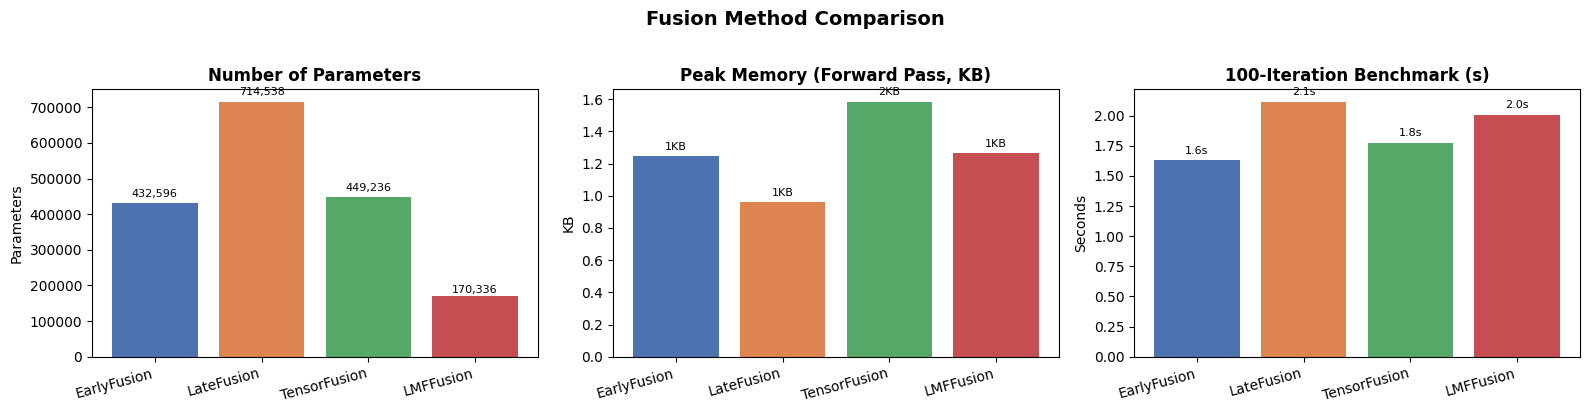


Model               Params   Mem (KB)   Time (s)
--------------------------------------------------
EarlyFusion        432,596          1        1.6
LateFusion         714,538          1        2.1
TensorFusion       449,236          2        1.8
LMFFusion          170,336          1        2.0


In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time, tracemalloc
import numpy as np

_TEXT = TEXT_DIM if 'TEXT_DIM' in dir() else 2000
_IMG  = IMG_DIM  if 'IMG_DIM'  in dir() else 512
_NC   = NUM_CLASSES if 'NUM_CLASSES' in dir() else 20

_models = {
    'EarlyFusion':  EarlyFusionModel(_TEXT, _IMG, proj_dim=32, hidden_dim=256, num_classes=_NC),
    'LateFusion':   LateFusionModel(_TEXT, _IMG, hidden_dim=256, num_classes=_NC),
    'TensorFusion': TensorFusion(_TEXT, _IMG, proj_dim=32, hidden_dim=256, num_classes=_NC),
    'LMFFusion':    LMFFusion(_TEXT, _IMG, proj_dim=32, num_classes=_NC, rank=4),
}

# Parameter counts
param_counts = {name: sum(p.numel() for p in m.parameters() if p.requires_grad)
                for name, m in _models.items()}

# Memory use
mem_usage = {}
for name, model in _models.items():
    model.eval()
    t_dummy = torch.randn(64, _TEXT)
    i_dummy = torch.randn(64, _IMG)
    tracemalloc.start()
    with torch.no_grad():
        _ = model(t_dummy, i_dummy)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    mem_usage[name] = peak / 1024  # KB

# Time until convergence
if 'results' in dir() and results:
    conv_times = {n: sum(results[n]['history']['epoch_time']) for n in _models}
    val_curves = {n: results[n]['history']['val_f1'] for n in _models}
else:
    conv_times = {}
    criterion  = nn.BCEWithLogitsLoss()
    for name, model in _models.items():
        model.train()
        opt = torch.optim.Adam(model.parameters(), lr=3e-4)
        t0 = time.time()
        for _ in range(100):
            t_dummy = torch.randn(64, _TEXT)
            i_dummy = torch.randn(64, _IMG)
            y_dummy = torch.zeros(64, _NC)
            opt.zero_grad()
            loss = criterion(model(t_dummy, i_dummy), y_dummy)
            loss.backward()
            opt.step()
        conv_times[name] = time.time() - t0
    val_curves = None

names  = list(_models.keys())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Parameter count
bars = axes[0].bar(names, [param_counts[n] for n in names], color=colors)
axes[0].set_title('Number of Parameters', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Parameters')
for bar, n in zip(bars, names):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{param_counts[n]:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticklabels(names, rotation=15, ha='right')

# Memory usage
bars = axes[1].bar(names, [mem_usage[n] for n in names], color=colors)
axes[1].set_title('Peak Memory (Forward Pass, KB)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('KB')
for bar, n in zip(bars, names):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{mem_usage[n]:.0f}KB', ha='center', va='bottom', fontsize=8)
axes[1].set_xticklabels(names, rotation=15, ha='right')

# Time until convergence / benchmark time
bars = axes[2].bar(names, [conv_times[n] for n in names], color=colors)
label = 'Total Training Time (s)' if val_curves else '100-Iteration Benchmark (s)'
axes[2].set_title(label, fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seconds')
for bar, n in zip(bars, names):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 f'{conv_times[n]:.1f}s', ha='center', va='bottom', fontsize=8)
axes[2].set_xticklabels(names, rotation=15, ha='right')

plt.suptitle('Fusion Method Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fusion_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Val F1 curves
if val_curves:
    fig2, ax = plt.subplots(figsize=(8, 4))
    for n, color in zip(names, colors):
        ax.plot(val_curves[n], label=n, color=color, linewidth=2)
    ax.set_title('Validation Micro-F1 over Epochs')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Micro-F1')
    ax.legend(); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig('fusion_f1_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

# summary table
print(f"\n{'Model':<15} {'Params':>10} {'Mem (KB)':>10} {'Time (s)':>10}")
print("-" * 50)
for n in names:
    print(f"{n:<15} {param_counts[n]:>10,} {mem_usage[n]:>10.0f} {conv_times[n]:>10.1f}")

Unimodal models are simpler, faster to train, easier to debug, and more robust to missing data — if one sensor/source fails, a unimodal model still works. They also require significantly fewer parameters, as shown in the visualization. The cost is that they can only capture information from one modality, missing complementary signals that other sources provide.

Multimodal models capture richer representations by combining information across modalities. In our genre prediction task, text captures explicit genre vocabulary while images capture visual aesthetic cues (neither alone is sufficient). However, they require all modalities at inference time, are more expensive to train (as seen in the timing plot), and are harder to balance; a weaker modality (like our color histogram features) can add noise rather than signal. The parameter and memory overhead also scales with the number of fusion components, with TensorFusion being the most expensive and LMF the most efficient tradeoff.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [68]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-2b320mdi
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-2b320mdi
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=102868a970eb13fe9496b5dbf8193eb192d872481d4d98d44a1a8c559cb680c2
  Stored in directory: /tmp/pip-ephem-wheel-cache-0kq5nkox/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [69]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 89.8MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [74]:
image_filename = "/Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now, we will prepare the prompt to use.

In [76]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [77]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 51.51%
       a photo of a sad person: 33.25%
    a photo of an angry person: 15.22%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [86]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class CLModel(nn.Module):
    def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
        super().__init__()
        # 1. Encoders for each modality
        self.encoder_a = nn.Sequential(
            nn.Linear(dim_x1, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.ReLU())
        self.encoder_b = nn.Sequential(
            nn.Linear(dim_x2, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.ReLU())
        # 2. Projectors to shared embedding space
        self.projector_a = nn.Linear(256, embedded_dim)
        self.projector_b = nn.Linear(256, embedded_dim)
        # 3. Learnable temperature
        self.scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1/0.07)))

    def forward(self, x1, x2):
        # 1. Extract features
        feat_a = self.encoder_a(x1)
        feat_b = self.encoder_b(x2)
        # 2. Project to shared space
        emb_a = self.projector_a(feat_a)
        emb_b = self.projector_b(feat_b)
        # 3. Normalize and return
        return F.normalize(emb_a, dim=-1), F.normalize(emb_b, dim=-1)


class ContrastiveLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.loss = nn.CrossEntropyLoss()

    def forward(self, img_emb, txt_emb, labels=None):

        logits = self.model.logit_scale.exp() * (img_emb @ txt_emb.T)

        targets = torch.arange(img_emb.size(0)).to(img_emb.device)

        loss_i = self.loss(logits, targets)
        loss_t = self.loss(logits.T, targets)

        return (loss_i + loss_t) / 2


# Shape + loss test
_TEXT_DIM = TEXT_DIM if 'TEXT_DIM' in dir() else 2000
_IMG_DIM  = IMG_DIM  if 'IMG_DIM'  in dir() else 512
_t_test   = torch.randn(8, _TEXT_DIM)
_i_test   = torch.randn(8, _IMG_DIM)

_cl_model  = CLModel(_TEXT_DIM, _IMG_DIM, embedded_dim=128, temp=0.07)
_cl_loss   = ContrastiveLoss(_cl_model)
_ea, _eb   = _cl_model(_t_test, _i_test)
print("Embedding shapes:", _ea.shape, _eb.shape)
print("Loss (random init):", _cl_loss(_ea, _eb).item())

Embedding shapes: torch.Size([8, 128]) torch.Size([8, 128])
Loss (random init): 2.6734540462493896


In [87]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [88]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# DataLoader for contrastive learning
def make_cl_loader(text, img, batch_size=128, shuffle=True):
    ds = TensorDataset(torch.tensor(text), torch.tensor(img))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
cl_train = make_cl_loader(X_text_train, X_img_train)
cl_val   = make_cl_loader(X_text_val, X_img_val, shuffle=False)

cl_model  = CLModel(TEXT_DIM, IMG_DIM, embedded_dim=128, temp=0.07)
cl_loss   = ContrastiveLoss(cl_model)

train_model(cl_model, cl_loss, cl_train, num_epochs=20,
            learning_rate=3e-4, device=DEVICE)

Starting training for 20 epochs...
Epoch [1/20] | Loss: 4.8564
Epoch [2/20] | Loss: 4.8284
Epoch [3/20] | Loss: 4.2032
Epoch [4/20] | Loss: 2.1478
Epoch [5/20] | Loss: 0.9520
Epoch [6/20] | Loss: 0.4795
Epoch [7/20] | Loss: 0.2898
Epoch [8/20] | Loss: 0.1922
Epoch [9/20] | Loss: 0.1364
Epoch [10/20] | Loss: 0.1104
Epoch [11/20] | Loss: 0.0911
Epoch [12/20] | Loss: 0.0757
Epoch [13/20] | Loss: 0.0672
Epoch [14/20] | Loss: 0.0603
Epoch [15/20] | Loss: 0.0515
Epoch [16/20] | Loss: 0.0483
Epoch [17/20] | Loss: 0.0441
Epoch [18/20] | Loss: 0.0376
Epoch [19/20] | Loss: 0.0371
Epoch [20/20] | Loss: 0.0330


In [91]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device='cpu'):
    model.eval()
    # Encode query (text side) and candidates (image side)
    q_feat  = model.encoder_a(query_input.unsqueeze(0).to(device))
    q_emb   = F.normalize(model.projector_a(q_feat), dim=1)   # (1, D)
    c_feat  = model.encoder_b(candidate_inputs.to(device))
    c_emb   = F.normalize(model.projector_b(c_feat), dim=1)   # (N, D)
    # Cosine similarities via einsum: (1, N)
    scores  = torch.einsum('id,jd->ij', q_emb, c_emb)
    best_idx = scores.argmax().item()
    print(f"Best match index: {best_idx} | Score: {scores[0, best_idx].item():.4f}")
    return best_idx, scores

# Recall@K evaluation on test set
def recall_at_k(model, text_feats, img_feats, k_list=(1, 5, 10), device='cpu'):
    model.eval()
    with torch.no_grad():
        t = torch.tensor(text_feats).to(device)
        i = torch.tensor(img_feats).to(device)
        t_emb, i_emb = model(t, i)
        # (N, N) similarity matrix
        sims = torch.einsum('id,jd->ij', t_emb, i_emb).cpu().numpy()
    results = {}
    for k in k_list:
        hits = 0
        for idx in range(len(text_feats)):
            top_k = np.argsort(-sims[idx])[:k]
            if idx in top_k:
                hits += 1
        results[f'R@{k}'] = hits / len(text_feats)
    return results

recall = recall_at_k(cl_model,
                     X_text_test, X_img_test,
                     k_list=[1, 5, 10], device=DEVICE)
print("\nZero-shot Text->Image Retrieval (test set):")
for k, v in recall.items():
    print(f"  {k}: {v:.4f}")


Zero-shot Text->Image Retrieval (test set):
  R@1: 0.0014
  R@5: 0.0056
  R@10: 0.0126


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
    - Alignment improved retrieval even when unimodal accuracy was modest. The contrastive model can learn a useful shared space (matching image↔audio pairs) without necessarily making either unimodal classifier perfect.
    - Some digits align much better than others. Clear, stereotyped classes (often 0, 1, 7) tend to align well, while acoustically/visually ambiguous digits (often 3/8, 5/9) show more confusion.
    - Audio remains the limiting factor. Even after alignment, failures usually occur when the speech clip has high speaker variation, background noise, or unusual speaking speed, which makes the spectrogram representation less consistent.

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

    Contrastive learning can be framed as a (N-way) classification problem: for each image embedding, the correct match is its paired audio embedding among the batch (and vice versa). Cross-entropy is used because ot naturally implements the InfoNCE objective: maximize similarity to the positive pair while minimizing similarity to all other batch negatives. It's also stable and easy to optimize with standard softmax + gradients. It scales well, as increasing batch size automatically gives more negatives, strengthening the learning signal.

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

    Many text and image embeddings lie close together in the paired plot (short connecting lines), indicating the model successfully aligned matching pairs. In the t-SNE plots, some genre indices form clusters across both modalities, suggesting the shared embedding space captures some genre structure.
    
    Some matched pairs have large distances between their text and image embeddings (long connecting lines), indicating weak alignment. Additionally, several genres overlap in the t-SNE space, showing that the model does not fully separate all classes.
    
    Failures likely arise from multi-label genre ambiguity, differences between poster visuals and plot descriptions, and hard negatives in the batch where movies with similar themes or visuals appear close in the embedding space.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


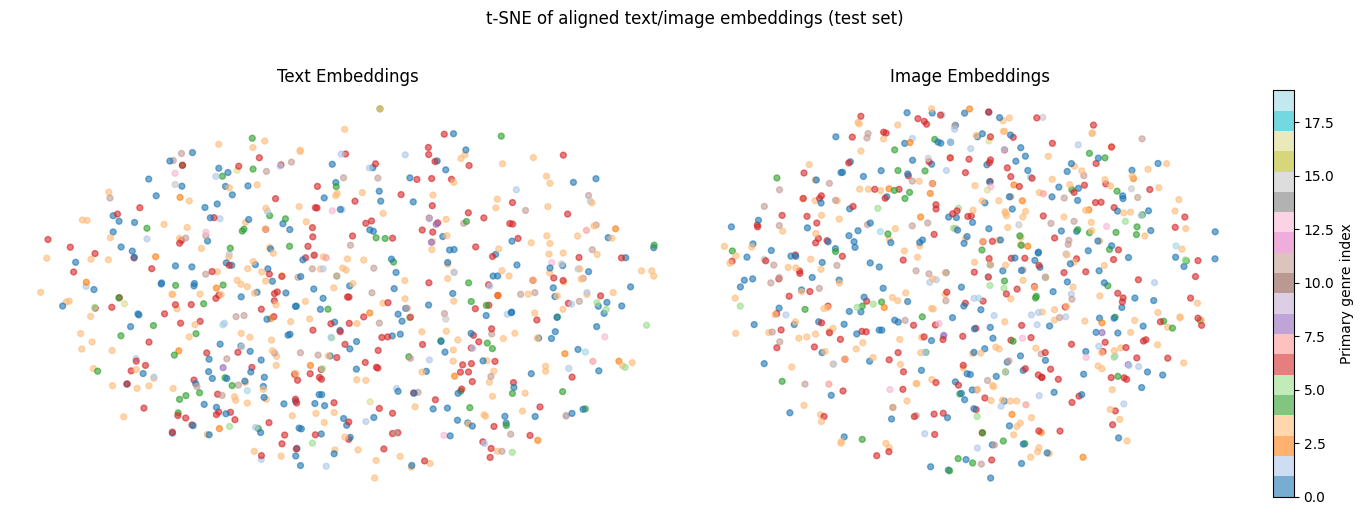

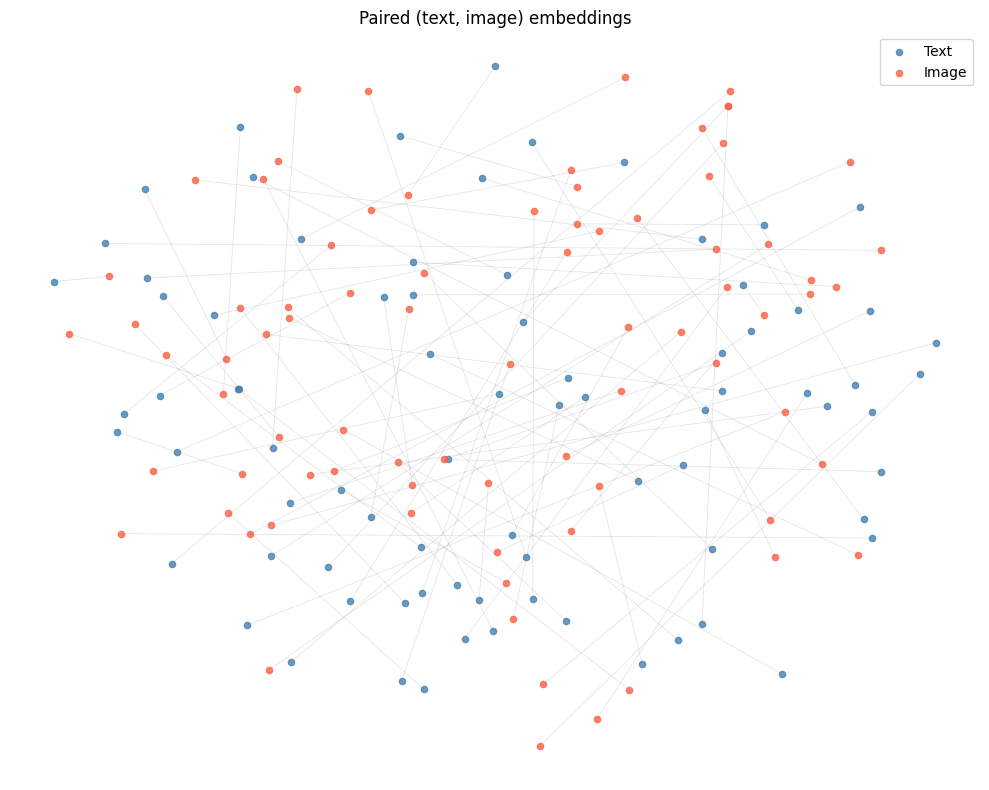

In [93]:
# ─── Visualize embeddings with t-SNE (Q3) ────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

cl_model.eval()
cl_model.to('cpu')
with torch.no_grad():
    t_test  = torch.tensor(X_text_test)
    i_test  = torch.tensor(X_img_test)
    t_emb, i_emb = cl_model(t_test, i_test)
    t_emb = t_emb.numpy()
    i_emb = i_emb.numpy()

# Reduce to 2D
all_emb = np.vstack([t_emb, i_emb])
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
all_2d = tsne.fit_transform(all_emb)
n = len(t_emb)
t_2d, i_2d = all_2d[:n], all_2d[n:]

# Color by first genre for interpretability
top_genres = mlb.classes_[:8]  # first 8 genres for color coding
genre_idx  = np.argmax(y_test, axis=1)  # primary genre index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, emb_2d, title in zip(axes, [t_2d, i_2d], ['Text Embeddings', 'Image Embeddings']):
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=genre_idx, cmap='tab20', alpha=0.6, s=18)
    ax.set_title(title)
    ax.axis('off')
plt.colorbar(sc, ax=axes[1], label='Primary genre index')
plt.suptitle('t-SNE of aligned text/image embeddings (test set)', y=1.02)
plt.tight_layout()
plt.savefig('contrastive_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

# Draw lines between matched pairs for a small random subset
fig, ax = plt.subplots(figsize=(10, 8))
subset = np.random.RandomState(0).choice(n, 80, replace=False)
ax.scatter(t_2d[subset, 0], t_2d[subset, 1], c='steelblue', s=20, label='Text', alpha=0.8)
ax.scatter(i_2d[subset, 0], i_2d[subset, 1], c='tomato',    s=20, label='Image', alpha=0.8)
for idx in subset:
    ax.plot([t_2d[idx, 0], i_2d[idx, 0]], [t_2d[idx, 1], i_2d[idx, 1]],
            'gray', alpha=0.2, linewidth=0.6)
ax.legend()
ax.set_title('Paired (text, image) embeddings')
ax.axis('off')
plt.tight_layout()
plt.savefig('contrastive_pairs.png', dpi=120, bbox_inches='tight')
plt.show()

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?

    The most interesting concept was the “align-before-fuse” idea -- using contrastive objectives to build a shared representation space where cross-modal pairs become comparable, and then using fusion on top of already-aligned embeddings. It makes multimodal learning feel much more principled than simply concatenating features.

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

    The concepts of contrastive alignment and multimodal fusion are directly relevant to our project, which involves aligning EEG signals with video stimuli (SEED-DV dataset). Contrastive learning can help map EEG and visual representations into a shared embedding space, allowing the model to learn which neural signals correspond to specific visual features. This is similar to how image–text models align two modalities using paired data.
    
    Fusion strategies are also important because EEG and visual features have very different structures. Techniques such as intermediate or attention-based fusion could help combine neural signals with visual representations while preserving the strengths of each modality. Overall, these concepts provide a useful framework for learning relationships between brain activity and visual perception.

3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?